In [2]:
# Kaggle basic __init__
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# All updates
!pip install --upgrade pip
!pip install --upgrade google-cloud-vision
!pip install --upgrade pip ipywidgets

!pip install -q -U bitsandbytes
!pip install -q -U accelerate
!pip install -q -U transformers

!pip install -q git+https://github.com/openai/CLIP.git

print("Done installing! Restarting kernel...")
os.kill(os.getpid(), 9)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.0 MB/s eta 0:00:0000:010:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 8.1.5
    Uninstalling ipywidgets-8.1.5:
      Successfully uninstalled ipywidgets-8.1.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
bigframes 2.8.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.31.0, but you have google-cloud-bigquery 3.25.0 which is incompatible.
bigframes 2.8.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are install

In [1]:
# All Imports
# ----------------------------------------- GOOGLE OCR API -------------------------------------------
from google.cloud import vision
import io
from io import BytesIO

# ---------------------------------------- ESSENTIAL IMPORTS -----------------------------------------
import os
import time
import requests
import chardet
from tqdm.notebook import tqdm

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from scipy.stats import mode

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, UnidentifiedImageError
import ast

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score

# ------------------------------------- DistilRoBERTa IMPORTS ----------------------------------------
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# ----------------------------------------- BLIP IMPORTS ---------------------------------------------
from transformers import BlipProcessor, BlipForConditionalGeneration

# ----------------------------------------- CLIP IMPORTS ---------------------------------------------
import clip

# ----------------------------------------- Torch IMPORTS --------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

2025-09-10 14:29:04.640585: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757514544.666362     146 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757514544.673667     146 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# ----------------------------------------- Essentials ---------------------------------------------
# Replace with your actual path to the JSON key file
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/kaggle/input/musait/manifest-canto-466706-v0-1bb68556dfe3.json"


SENTIMENTS_TO_LABELS = {'negative':0,'neutral':1,'positive':2}
LABELS_TO_SENTIMENTS = {0:'negative',1:'neutral',2:"positive"}


text_model_name = "distilroberta-base"
blip_model_name = "Salesforce/blip-image-captioning-base"
image_model_name = "ViT-B/32"


num_classes = 3
embed_dim = 512


# Set the device to GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Channels

## Text-detection

In [38]:
def check_text_detection(image_path):
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    client = vision.ImageAnnotatorClient()
    
    image = vision.Image(content=content)
    text = None
    
    response = client.text_detection(image=image)
    texts = response.text_annotations
    # print(texts)
    return texts[0] if texts else False

## Orientation

In [4]:
standard_ratios = {
    "1:1": 1.0,       # 1
    "4:3": 4/3,       # 1.33
    "3:2": 3/2,       # 1.5
    "16:9": 16/9,     # 1.78
    "5:4": 5/4,       # 1.25
    "21:9": 21/9,     # 2.33
    "2:1": 2.0,       # 2
    "7:5": 7/5,       # 1.4
    "1.41:1": 1.41,   # 1.41 (A4)
    "3:4": 3/4,       # 0.75
    "2:3": 2/3,       # 0.67
    "9:16": 9/16,     # 0.5625
    "5:7": 5/7,       # 0.71
    "4:5": 4/5,       # 0.8
    "1:√2": 1/1.414,  # 0.707 (A-series)
    "2:5": 2/5,       # 0.4
    "Other": 0
}


def closest_standard_ratio(width, height, tolerance=0.05):
    if height == 0:
        return "Invalid"
    ratio = width / height
    for name, std_ratio in standard_ratios.items():
        if abs(ratio - std_ratio) <= tolerance:
            return name
    return "Other"


aspect_ratio_orientation = {
    "1:1": "box",
    "4:3": "horizontal",      # 1.33
    "3:2": "horizontal",      # 1.5
    "16:9": "horizontal",     # 1.78
    "5:4": "horizontal",      # 1.25
    "21:9": "horizontal",     # 2.33
    "2:1": "horizontal",      # 2.0
    "7:5": "horizontal",      # 1.4
    "1.41:1": "horizontal",   # 1.41
    "3:4": "vertical",        # 0.75
    "2:3": "vertical",        # 0.666
    "9:16": "vertical",       # 0.5625
    "5:7": "vertical",        # 0.714
    "4:5": "vertical",        # 0.8
    "1:√2": "vertical",       # 0.707 (A-series)
    "2:5": "vertical",        # 0.4
    "Other": "box"
}

In [5]:
def image_orientation(image_path):
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    
    pil_image = Image.open(io.BytesIO(content))
    img_width, img_height = pil_image.size
    img_area = img_width*img_height
    
    img_area = img_width * img_height
    img_ar = closest_standard_ratio(img_width, img_height)
    img_ort = aspect_ratio_orientation[img_ar]
    img_ort_sentiments = list(or_dist[img_ort])
    return img_ort_sentiments, img_area



def text_orientation(texts, img_area):
    text = texts.description
    bounding_poly = texts.bounding_poly
    coordinates = []
    for vertex in bounding_poly.vertices:
        coordinates.append({"x": vertex.x, "y": vertex.y})
    
    x_values = [point['x'] for point in coordinates]
    y_values = [point['y'] for point in coordinates]
    txt_width = max(x_values) - min(x_values)
    txt_height = max(y_values) - min(y_values)

    txt_area = txt_width*txt_height
    txt_weightage = txt_area/img_area
    txt_ar = closest_standard_ratio(txt_width, txt_height)
    txt_ort = aspect_ratio_orientation[txt_ar]
    txt_ort_sentiments = list(or_dist[txt_ort])
    return txt_ort_sentiments, txt_weightage



## DistilRoBERTa

In [6]:
# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(text_model_name)
text_model = AutoModelForSequenceClassification.from_pretrained(text_model_name, num_labels=num_classes)

text_model.to(device)

# Load your fine-tuned weights
state_dict = torch.load("/kaggle/input/best-models-musait/TSA/DistilRoBERTa__best_model.pt", map_location=device)
text_model.load_state_dict(state_dict)  # Should match now
text_model.eval()

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
           

In [7]:
def preprocess(text, tokenizer, max_length=128):
    return tokenizer(
        text,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )


text_tokenizer = AutoTokenizer.from_pretrained(text_model_name)

## BLIP

In [8]:
blip_processor = BlipProcessor.from_pretrained(blip_model_name)
blip_model = BlipForConditionalGeneration.from_pretrained(blip_model_name).to(device)

blip_model.to(device)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

## CLIP

In [9]:
class CLIPClassifier(nn.Module):
    def __init__(self, encoder, embed_dim, num_classes):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, image):
        image = image.to(dtype=self.encoder.conv1.weight.dtype)  # usually float16
        with torch.no_grad():
            x = self.encoder(image)
        x = x.float()  # Convert back to float32 for classifier
        return self.classifier(x)

In [10]:
clip_model, image_preprocess = clip.load(image_model_name, device=device)
image_encoder = clip_model.visual

image_model = CLIPClassifier(image_encoder, embed_dim=embed_dim, num_classes=num_classes).to(device)

image_model.load_state_dict(torch.load("/kaggle/input/best-models-musait/VSA/CLIP__best_model.pt"))
image_model.eval()

100%|███████████████████████████████████████| 338M/338M [00:17<00:00, 19.8MiB/s]


CLIPClassifier(
  (encoder): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)

## All-in-one initialization

In [ ]:
def check_text_detection(image_path):
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    client = vision.ImageAnnotatorClient()
    
    image = vision.Image(content=content)
    text = None
    
    response = client.text_detection(image=image)
    texts = response.text_annotations
    return texts[0] if texts else False

standard_ratios = {
    "1:1": 1.0,       # 1
    "4:3": 4/3,       # 1.33
    "3:2": 3/2,       # 1.5
    "16:9": 16/9,     # 1.78
    "5:4": 5/4,       # 1.25
    "21:9": 21/9,     # 2.33
    "2:1": 2.0,       # 2
    "7:5": 7/5,       # 1.4
    "1.41:1": 1.41,   # 1.41 (A4)
    "3:4": 3/4,       # 0.75
    "2:3": 2/3,       # 0.67
    "9:16": 9/16,     # 0.5625
    "5:7": 5/7,       # 0.71
    "4:5": 4/5,       # 0.8
    "1:√2": 1/1.414,  # 0.707 (A-series)
    "2:5": 2/5,       # 0.4
    "Other": 0
}


def closest_standard_ratio(width, height, tolerance=0.05):
    if height == 0:
        return "Invalid"
    ratio = width / height
    for name, std_ratio in standard_ratios.items():
        if abs(ratio - std_ratio) <= tolerance:
            return name
    return "Other"


aspect_ratio_orientation = {
    "1:1": "box",
    "4:3": "horizontal",      # 1.33
    "3:2": "horizontal",      # 1.5
    "16:9": "horizontal",     # 1.78
    "5:4": "horizontal",      # 1.25
    "21:9": "horizontal",     # 2.33
    "2:1": "horizontal",      # 2.0
    "7:5": "horizontal",      # 1.4
    "1.41:1": "horizontal",   # 1.41
    "3:4": "vertical",        # 0.75
    "2:3": "vertical",        # 0.666
    "9:16": "vertical",       # 0.5625
    "5:7": "vertical",        # 0.714
    "4:5": "vertical",        # 0.8
    "1:√2": "vertical",       # 0.707 (A-series)
    "2:5": "vertical",        # 0.4
    "Other": "box"
}

def image_orientation(image_path):
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    
    pil_image = Image.open(io.BytesIO(content))
    img_width, img_height = pil_image.size
    img_area = img_width*img_height
    
    img_area = img_width * img_height
    img_ar = closest_standard_ratio(img_width, img_height)
    img_ort = aspect_ratio_orientation[img_ar]
    img_ort_sentiments = list(or_dist[img_ort])
    return img_ort_sentiments, img_area



def text_orientation(texts, img_area):
    text = texts.description
    bounding_poly = texts.bounding_poly
    coordinates = []
    for vertex in bounding_poly.vertices:
        coordinates.append({"x": vertex.x, "y": vertex.y})
    
    x_values = [point['x'] for point in coordinates]
    y_values = [point['y'] for point in coordinates]
    txt_width = max(x_values) - min(x_values)
    txt_height = max(y_values) - min(y_values)

    txt_area = txt_width*txt_height
    txt_weightage = txt_area/img_area
    txt_ar = closest_standard_ratio(txt_width, txt_height)
    txt_ort = aspect_ratio_orientation[txt_ar]
    txt_ort_sentiments = list(or_dist[txt_ort])
    return txt_ort_sentiments, txt_weightage




# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(text_model_name)
text_model = AutoModelForSequenceClassification.from_pretrained(text_model_name, num_labels=num_classes)

text_model.to(device)

# Load your fine-tuned weights
state_dict = torch.load("/kaggle/input/best-models-musait/TSA/DistilRoBERTa__best_model.pt", map_location=device)
text_model.load_state_dict(state_dict)  # Should match now
text_model.eval()

def preprocess(text, tokenizer, max_length=128):
    return tokenizer(
        text,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )


text_tokenizer = AutoTokenizer.from_pretrained(text_model_name)





blip_processor = BlipProcessor.from_pretrained(blip_model_name)
blip_model = BlipForConditionalGeneration.from_pretrained(blip_model_name).to(device)

blip_model.to(device)




class CLIPClassifier(nn.Module):
    def __init__(self, encoder, embed_dim, num_classes):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, image):
        image = image.to(dtype=self.encoder.conv1.weight.dtype)  # usually float16
        with torch.no_grad():
            x = self.encoder(image)
        x = x.float()  # Convert back to float32 for classifier
        return self.classifier(x)

clip_model, image_preprocess = clip.load(image_model_name, device=device)
image_encoder = clip_model.visual

image_model = CLIPClassifier(image_encoder, embed_dim=embed_dim, num_classes=num_classes).to(device)

image_model.load_state_dict(torch.load("/kaggle/input/best-models-musait/VSA/CLIP__best_model.pt"))
image_model.eval()

# MuSAIT model

In [39]:
def MuSAIT(filepath, allow_orientation=0):
    text = None
    texts = check_text_detection(filepath)
    # alpha = 0.5
    alpha = 0.11006431308155445
    if texts:
        text = texts.description
        
    else:
        print("-"*100)
        print("Caution: There exists no text inside image. Predictions might be flawed!")
        print("-"*100)
        time.sleep(1) # 1000 ms
        print("Generating caption for the image...")
        print("Loading...!")
        time.sleep(1) # 1000 ms
        print("Generating caption for the image...")
        # BLIP-2 Image Caption Generation
        raw_image = Image.open(filepath).convert('RGB')
        inputs = blip_processor(images=raw_image, return_tensors="pt").to(device, torch.float16)
        generated_ids = blip_model.generate(**inputs)
        text = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
        print(f"Generated image caption: {text}")

    # DistilRoBERTa tokenization
    inputs = text_tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = text_model(**inputs)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=1)
    
    prob_text = np.array(probs.squeeze().tolist())
    pred_class_text = np.argmax(prob_text)

    image = None 
    image_preprocessed = None
    try:
        image = Image.open(filepath)
        image_preprocessed = image_preprocess(image).unsqueeze(0).to(device)
    except (OSError, UnidentifiedImageError, FileNotFoundError) as e:
        print(f"File: {ID}.jpg is an INVALID image file")
        return
    except Exception as e:
        print(f"Unexpected error: {e}")
        return
        
    pred_class_clip = -1
    
    # Inference
    with torch.no_grad():
        output = image_model(image_preprocessed)
        # Get the predicted class index
        
        probs = F.softmax(output, dim=1)  # Shape: (1, 3)
        prob_img = np.array(probs.squeeze().tolist())  # Shape: (3,)
        pred_class_image = output.argmax(dim=1).item()

    plt.imshow(image)
    plt.axis('off')
    plt.title("Input image")
    plt.show()
    
    prob_total = alpha * prob_text + (1 - alpha) * prob_img
    pred_class = np.argmax(prob_total)

    print("_"*50)
    print("RESULTS")
    print("_"*50)
    print(f"Predicted sentiment : {LABELS_TO_SENTIMENTS[pred_class]}")
    print(f"Confidence score: {prob_total[pred_class]*100:.3f}")
    print(f"\nChannel wise predicted sentiment (text, image): ({LABELS_TO_SENTIMENTS[pred_class_text]},{LABELS_TO_SENTIMENTS[pred_class_image]})")
    print(f"\nChannel wise predicted sentiment (text, image): ({prob_text[pred_class_text]:.3f},{prob_img[pred_class_image]:.3f})")
    print("_"*50)
    print("Thank you!")

## Trial inference

Try the following instances:
- negative_050.jpg
- negative_188.jpg
- neutral_302.jpeg
- positive_651.jpg
- positive_766.jpg

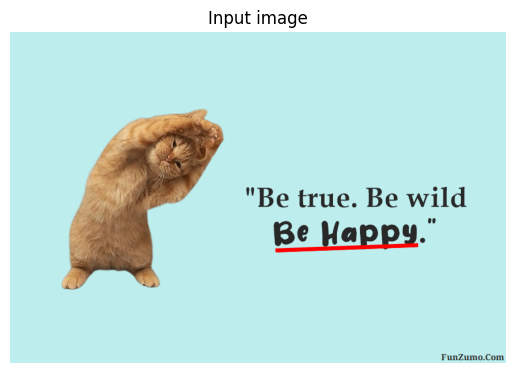

__________________________________________________
RESULTS
__________________________________________________
Predicted sentiment : positive
Confidence score: 89.192

Channel wise predicted sentiment (text, image): (positive,positive)

Channel wise predicted sentiment (text, image): (0.999,0.879)
__________________________________________________
Thank you!


In [41]:
MuSAIT("/kaggle/input/musait/basket_unique/positive_651.jpg")

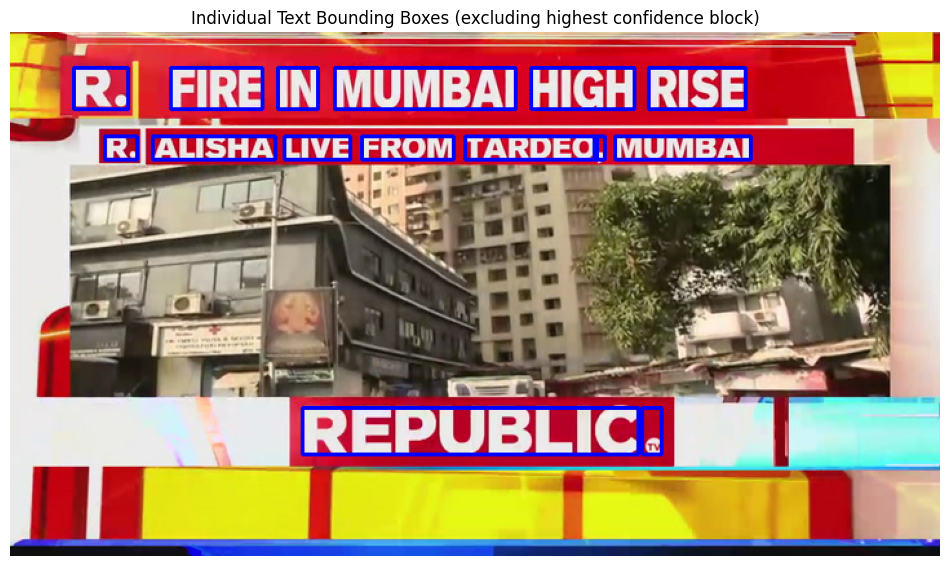

In [32]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Load your image
image_path = '/kaggle/input/musait/basket_unique/negative_188.jpg'  # Replace with your actual image path
image = Image.open(image_path)

# Create a drawing context
draw = ImageDraw.Draw(image)

# Define all bounding boxes (skipping the first one)
bounding_boxes = [
    # Each item is a list of 4 tuples (x, y)
    [(49, 28), (91, 28), (91, 60), (49, 60)],        # "R."
    [(124, 28), (195, 28), (195, 60), (124, 60)],    # "FIRE"
    [(207, 28), (238, 28), (238, 60), (207, 60)],    # "IN"
    [(251, 28), (391, 28), (391, 60), (251, 60)],    # "MUMBAI"
    [(403, 28), (483, 28), (483, 60), (403, 60)],    # "HIGH"
    [(494, 28), (569, 28), (569, 60), (494, 60)],    # "RISE"
    [(73, 81), (98, 81), (98, 99), (73, 99)],        # "R."
    [(110, 81), (205, 81), (205, 99), (110, 99)],    # "ALISHA"
    [(212, 81), (263, 81), (263, 99), (212, 99)],    # "LIVE"
    [(272, 81), (343, 81), (343, 99), (272, 99)],    # "FROM"
    [(352, 81), (454, 81), (454, 99), (352, 99)],    # "TARDEO"
    [(452, 81), (460, 81), (460, 99), (452, 99)],    # ","
    [(468, 81), (573, 81), (573, 99), (468, 99)],    # "MUMBAI"
    [(226, 291), (486, 291), (486, 327), (226, 327)],# "REPUBLIC"
    [(489, 291), (504, 291), (504, 327), (489, 327)] # "."
]

# Draw all bounding boxes (excluding the first big one)
for box in bounding_boxes:
    draw.line(box + [box[0]], fill='blue', width=3)

# Show the image with bounding boxes
plt.figure(figsize=(12, 10))
plt.imshow(image)
plt.axis('off')
plt.title("Individual Text Bounding Boxes (excluding highest confidence block)")
plt.show()

In [35]:
total_area = 0

for box in bounding_boxes:
    x1, y1 = box[0]
    x2, y2 = box[1]
    x4, y4 = box[3]

    width = abs(x2 - x1)
    height = abs(y4 - y1)

    area = width * height
    total_area += area

print(f"Total area covered by all bounding boxes: {total_area} pixels²")
width, height = image.size
img_area = width*height
print(f"Total area covered the image: {img_area} pixels²")
print(f"Text proportion inside image: {total_area/img_area}")

Total area covered by all bounding boxes: 32174 pixels²
Total area covered the image: 292320 pixels²
Text proportion inside image: 0.11006431308155445
